# HHL algorithm, an example

In [1]:
from hhl_2x2_sketch import *
import matplotlib.pyplot as plt

In [2]:
# Define the linear system
A = np.array([[1.0, -1.0 / 3.0], [-1.0 / 3.0, 1.0]])
b_vec = np.array([1.0, 0.0])

N_b = 2

# Classical solution 
x_cl = np.linalg.solve(A, b_vec)
x_cl_norm = x_cl / np.linalg.norm(x_cl)

print(x_cl_norm[0]**2)
print(x_cl_norm[1]**2)

# Spectral analysis
evd_A = np.linalg.eig(A)

0.8999999999999999
0.1


In [3]:
x_cl
evd_A.eigenvalues

max(evd_A.eigenvalues) / min(evd_A.eigenvalues)

np.float64(1.9999999999999998)

## Quantum emulator

In [4]:
# Here we use the optimal parameters for the algorithms, i.e.
# -> C = min(\lambda_j)
# -> t s.t. N_c \lambda_j t / (2\pi) integers \forall j
# -> t < 2\pi/\max{\lambda_j}
# -> n_c s.t. N_c > \max{\lambda_j}/\min{\lambda_j}=\kappa

n_c = 2
N_c = 2**n_c

print(N_c > max(evd_A.eigenvalues) / min(evd_A.eigenvalues))


evolution_time = 1/2*(2 * np.pi / max(evd_A.eigenvalues))  #3 * np.pi / 4 

print(evolution_time * evd_A.eigenvalues * N_c / np.pi / 2)

hhl_confguration = HHLConfig(
    phase_qubits = n_c,
    evolution_time =  evolution_time,
    reciprocal_scale = min(evd_A.eigenvalues),  # must satisfy C ≤ λ_min
    trotter_steps = 1    
)

# Quantum alternative
quantum_solver = HHLAlgorithm(config=hhl_confguration)


True
[2. 1.]


In [5]:
# Visualise the circuit
quantum_solver.build_circuit(A, b_vec).draw(
    output="mpl", filename="docs/beamer-slides/plots/circuit-mpl.jpeg", scale=1, fold=30)

transpiled = transpile(quantum_solver.build_circuit(A, b_vec), BasicSimulator())
print(transpiled.depth())

37


/Users/marcogalliani/Projects/hhl/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/marcogalliani/Projects/hhl/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


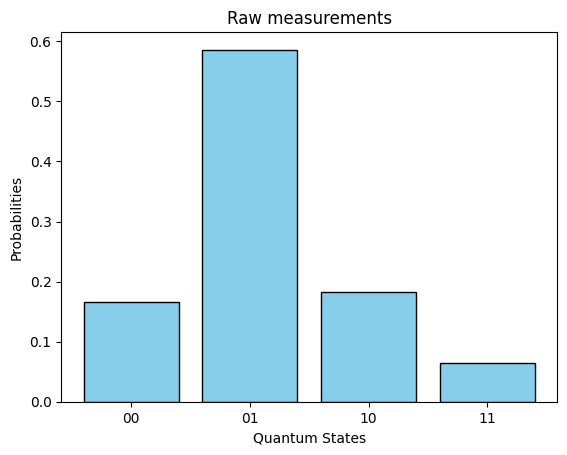

In [6]:
# Raw counts
shots = 1000
res_counts = quantum_solver.run_circuit(shots)
res_counts = dict(sorted(res_counts.items())) # Sorts keys to 00, 01, 10, 11

# Compute the probabilities
probabilities = {outcome: count / shots for outcome, count in sorted(res_counts.items())}
success_probs = {o: p for o, p in probabilities.items() if o.endswith("1")}
success_probs

plt.bar(probabilities.keys(), probabilities.values(), color='skyblue', edgecolor='black')
plt.xlabel('Quantum States')
plt.ylabel('Probabilities')
plt.title('Raw measurements')

plt.savefig("docs/beamer-slides/plots/emulator-raw-measurements.jpeg", dpi=300, bbox_inches='tight')
plt.show()

0.651
0.6250000000000002


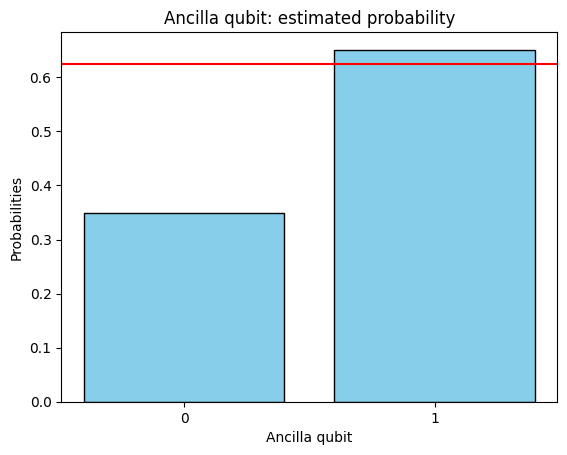

In [7]:
# ancilla qubit
p_anc1 = sum(success_probs.values())
print(p_anc1)

prob_ancilla = {"0": 1-p_anc1, "1": p_anc1}

# theoretical amplitude
beta_vec = np.linalg.solve(evd_A.eigenvectors, b_vec)

theoretical_prob = np.sum(np.pow(beta_vec * hhl_confguration.reciprocal_scale/evd_A.eigenvalues,2))
print(theoretical_prob)

plt.bar(prob_ancilla.keys(), prob_ancilla.values(), color='skyblue', edgecolor='black')
plt.axhline(y=theoretical_prob, color='r', linestyle='-')
plt.xlabel('Ancilla qubit')
plt.ylabel('Probabilities')
plt.title('Ancilla qubit: estimated probability')

plt.savefig("docs/beamer-slides/plots/emulator-prob-anc.jpeg", dpi=300, bbox_inches='tight')
plt.show()

{'01': 0.9001536098310291, '11': 0.09984639016897082}


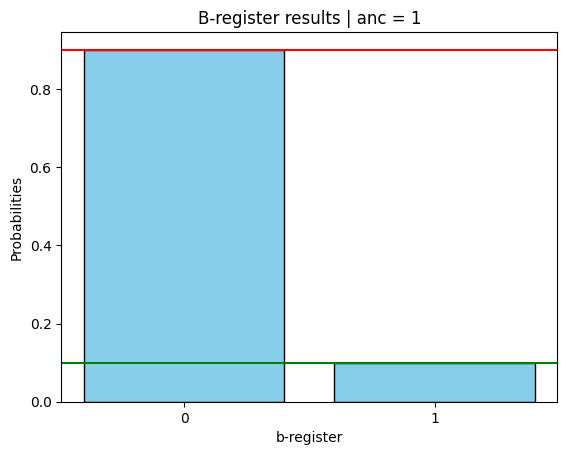

In [8]:
# Conditional probabilities
conditional = {o: p / p_anc1 for o, p in success_probs.items()} if p_anc1 > 0 else {}
print(conditional)

plt.bar(["0","1"], conditional.values(), color='skyblue', edgecolor='black')
plt.axhline(y=x_cl_norm[0]**2, color='r', linestyle='-')
plt.axhline(y=x_cl_norm[1]**2, color='g', linestyle='-')
plt.xlabel('b-register')
plt.ylabel('Probabilities')
plt.title('B-register results | anc = 1')

plt.savefig("docs/beamer-slides/plots/emulator-conditional-anc1.jpeg", dpi=300, bbox_inches='tight')
plt.show()

## Example on quantum hardware

In [ ]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=os.environ["QISKIT_IBM_TOKEN"]
)
backend = service.least_busy(operational=True, min_num_qubits=4)

IBM_quantum_solver = HHLAlgorithm(
    config=hhl_confguration, 
    backend=backend
    )
circuit = IBM_quantum_solver.build_circuit(A, b_vec)

isa = generate_preset_pass_manager(backend=backend, optimization_level=3).run(circuit)
print(isa.depth())

qiskit_runtime_service._discover_account:WARNING:2026-05-26 23:17:36,293: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-26 23:17:40,779: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-26 23:17:42,299: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-26 23:17:46,025: Using instance: open-instance, plan: open


218


/Users/marcogalliani/Projects/hhl/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/marcogalliani/Projects/hhl/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


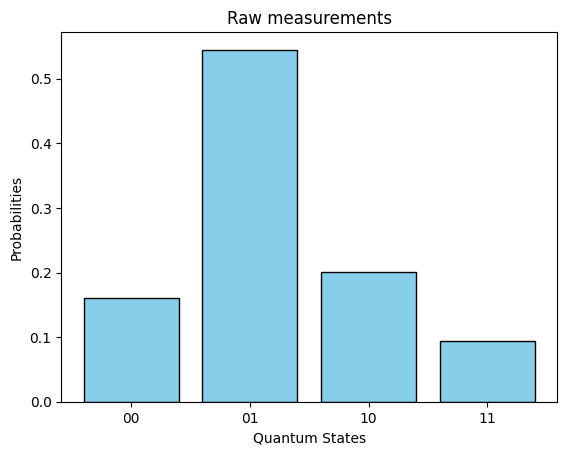

In [25]:
# Raw counts
shots = 1000
res_counts = IBM_quantum_solver.run_circuit(shots)
res_counts = dict(sorted(res_counts.items())) # Sorts keys to 00, 01, 10, 11

# Compute the probabilities
probabilities = {outcome: count / shots for outcome, count in sorted(res_counts.items())}
success_probs = {o: p for o, p in probabilities.items() if o.endswith("1")}
success_probs

plt.bar(probabilities.keys(), probabilities.values(), color='skyblue', edgecolor='black')
plt.xlabel('Quantum States')
plt.ylabel('Probabilities')
plt.title('Raw measurements')

plt.savefig("docs/beamer-slides/plots/ibm-raw-measurements.jpeg", dpi=300, bbox_inches='tight')
plt.show()

0.639
0.6250000000000002


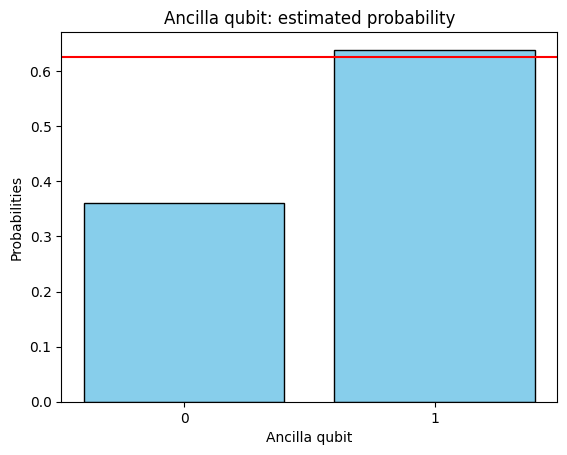

In [26]:
# ancilla qubit
p_anc1 = sum(success_probs.values())
print(p_anc1)

prob_ancilla = {"0": 1-p_anc1, "1": p_anc1}

# theoretical amplitude
beta_vec = np.linalg.solve(evd_A.eigenvectors, b_vec)

theoretical_prob = np.sum(np.pow(beta_vec * hhl_confguration.reciprocal_scale/evd_A.eigenvalues,2))
print(theoretical_prob)

plt.bar(prob_ancilla.keys(), prob_ancilla.values(), color='skyblue', edgecolor='black')
plt.axhline(y=theoretical_prob, color='r', linestyle='-')
plt.xlabel('Ancilla qubit')
plt.ylabel('Probabilities')
plt.title('Ancilla qubit: estimated probability')

plt.savefig("docs/beamer-slides/plots/ibm-prob-anc.jpeg", dpi=300, bbox_inches='tight')
plt.show()

{'01': 0.8528951486697967, '11': 0.14710485133020343}


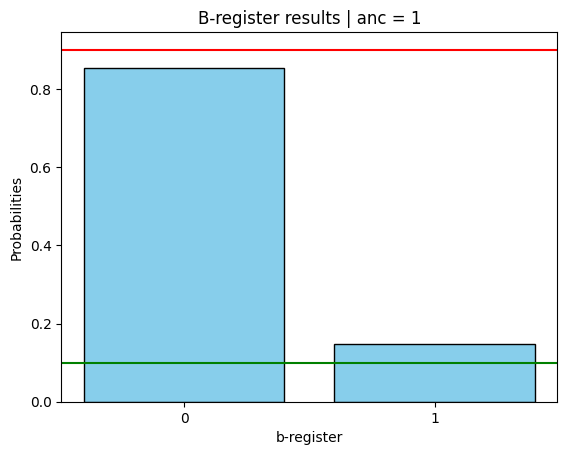

In [27]:
# Conditional probabilities
conditional = {o: p / p_anc1 for o, p in success_probs.items()} if p_anc1 > 0 else {}
print(conditional)

plt.bar(["0","1"], conditional.values(), color='skyblue', edgecolor='black')
plt.axhline(y=x_cl_norm[0]**2, color='r', linestyle='-')
plt.axhline(y=x_cl_norm[1]**2, color='g', linestyle='-')
plt.xlabel('b-register')
plt.ylabel('Probabilities')
plt.title('B-register results | anc = 1')

plt.savefig("docs/beamer-slides/plots/ibm-conditional-anc1.jpeg", dpi=300, bbox_inches='tight')
plt.show()

### Debugging on quantum solver
cCheck the status of the c-registers before uncomputation to see if phase is correctly estimated

In [14]:
res = IBM_quantum_solver.simulate_pre_uncompute(A, b_vec, shots=50000)

In [16]:
from collections import defaultdict

print("Outcome (phase_1 phase_0 sys anc)   P(raw)    P(|anc=1)")
print("-" * 56)
for o, p in res.raw.items():
    cond = f"{res.conditional[o]:.4f}" if o in res.conditional else "  —  "
    print(f"  {o:<34} {p:.4f}    {cond}")

print()
by_phase = defaultdict(lambda: {"total": 0.0, "anc1": 0.0})
for o, p in res.raw.items():
    phase_bits = o[:-2]
    by_phase[phase_bits]["total"] += p
    if o.endswith("1"):
        by_phase[phase_bits]["anc1"] += p

theory = {"01": 1.0, "10": 0.25}
print("Phase register (j=1→'01', j=2→'10' expected):")
print(f"  {'phase':>6}  {'P(phase)':>10}  {'P(anc=1|phase)':>16}  {'theory':>8}")
for phase, d in sorted(by_phase.items()):
    p_anc = d["anc1"] / d["total"] if d["total"] > 0 else 0
    th = theory.get(phase, 0.0)
    print(f"  {phase:>6}  {d['total']:>10.4f}  {p_anc:>16.4f}  {th:>8.4f}")

Outcome (phase_1 phase_0 sys anc)   P(raw)    P(|anc=1)
--------------------------------------------------------
  0000                               0.0097      —  
  0001                               0.0108    0.0189
  0010                               0.0099      —  
  0011                               0.0114    0.0200
  0100                               0.0150      —  
  0101                               0.1955    0.3418
  0110                               0.0161      —  
  0111                               0.2076    0.3629
  1000                               0.1868      —  
  1001                               0.0681    0.1190
  1010                               0.1711      —  
  1011                               0.0648    0.1133
  1100                               0.0093      —  
  1101                               0.0066    0.0116
  1110                               0.0099      —  
  1111                               0.0072    0.0127

Phase register (j=1→'01', j=2→